# Bandit benchmark notebook

Этот ноутбук запускает benchmark-пайплайн (аналогично `src/run_benchmark.py`) на вашем датасете.

## 1) Настройки

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import polars as pl

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from run_benchmark import load_dataset
from bandit_benchmark import (
    CatBoostPolicy,
    LogisticTSLibPolicy,
    LaplaceThompsonViaBayesianLogRegPolicy,
    NeuralLaplaceThompsonViaBayesianLogRegPolicy,
    PartitionedTSLibPolicy,
    RandomPolicy,
    EpsilonGreedyPolicy,
    UCBPolicy,
    ThompsonSamplingPolicy,
    TreeThompsonSamplingPolicy,
    _NeuralActionRewardEncoder,
    build_expected_reward_estimator,
    core_scenarios,
    default_five_scenarios,
    make_simulated_environment,
    preprocess_bandit_dataframe,
    run_scenarios,
    split_train_test_by_date,
)
from prepare_datasets import stage1_make_splits, stage2_scale_features


In [2]:
# Укажите путь к данным (.tsv или .parquet)
DATA_PATH = ROOT / 'data' / 'banner_big.tsv'
DATASET_NAME = DATA_PATH.stem
ARTIFACTS_DIR = ROOT / 'artifacts' / DATASET_NAME
DATASETS_DIR = ARTIFACTS_DIR / 'datasets'

PREPARED_TRAIN_PATH = DATASETS_DIR / 'train_variant_1_scaled.parquet'
PREPARED_TEST_PATH = DATASETS_DIR / 'test_variant_1_scaled.parquet'

USE_PREPARED_SPLITS = True
TRAIN_DAYS = 20
EPSILON = 0.1
SEED = 42
SIMULATE = False
STOCHASTIC_SIM = True
FULL_SCENARIOS = False
NEURAL_HIDDEN_DIMS = [256, 256]
USE_SAMPLED_DATASET = False
SAMPLE_FRACTION = 0.2  # доля строк для train/test при демо-прогоне
USE_CUSTOM_ENCODER = True
ENCODER_REP_DIM = 64
ENCODER_NN_LR = 1e-3


## 2) Загрузка и препроцессинг

In [3]:
if USE_PREPARED_SPLITS and PREPARED_TRAIN_PATH.exists() and PREPARED_TEST_PATH.exists():
    train_df = pl.read_parquet(PREPARED_TRAIN_PATH)
    test_df = pl.read_parquet(PREPARED_TEST_PATH)
    print('loaded prepared splits')
else:
    # Stage 1: load -> split -> filter -> save
    train_s1, test_s1 = stage1_make_splits(str(DATA_PATH), str(DATASETS_DIR), TRAIN_DAYS, SEED)
    # Stage 2: scale features and save prepared datasets
    train_final, test_final = stage2_scale_features(train_s1, test_s1, str(DATASETS_DIR))
    train_df = pl.read_parquet(train_final)
    test_df = pl.read_parquet(test_final)

print('train:', train_df.height, 'test(random only):', test_df.height)


train: 229629 test(random only): 390299


## 3) Конфиг политик и сценариев

In [4]:
policy_factories = {
    'random': lambda: RandomPolicy(seed=SEED),
    'epsilon_greedy': lambda: EpsilonGreedyPolicy(epsilon=EPSILON, seed=SEED),
    'ucb': lambda: UCBPolicy(),
    'thompson_sampling': lambda: ThompsonSamplingPolicy(seed=SEED),
}

try:
    import sklearn  # noqa: F401
    policy_factories['tree_thompson_sampling_refit'] = lambda: TreeThompsonSamplingPolicy(random_state=SEED, refit_when_update=True)
    policy_factories['tree_thompson_sampling_no_refit'] = lambda: TreeThompsonSamplingPolicy(random_state=SEED, refit_when_update=False)
except Exception:
    print('sklearn is unavailable: skipping TreeThompsonSamplingPolicy')
try:
    import scipy  # noqa: F401
    policy_factories['laplace_ts_logreg'] = lambda: LaplaceThompsonViaBayesianLogRegPolicy(seed=SEED)
    try:
        import torch  # noqa: F401
        custom_encoder = None
        if USE_CUSTOM_ENCODER:
            feature_rows = train_df.select('features_list').to_series().to_list()
            non_empty_features = [row for row in feature_rows if isinstance(row, list) and len(row) > 0]
            if non_empty_features:
                feature_dim = len(non_empty_features[0])
                action_count = train_df.select('show').n_unique()
                custom_encoder = _NeuralActionRewardEncoder(
                    input_dim=feature_dim,
                    num_actions=action_count,
                    hidden_dims=NEURAL_HIDDEN_DIMS,
                    rep_dim=ENCODER_REP_DIM,
                    lr=ENCODER_NN_LR,
                    seed=SEED,
                )
            else:
                print('train_df has no non-empty features_list rows: encoder will be created by policy itself')
        policy_factories['neural_laplace_ts_logreg'] = lambda: NeuralLaplaceThompsonViaBayesianLogRegPolicy(
            seed=SEED,
            network_architecture=NEURAL_HIDDEN_DIMS,
            encoder=custom_encoder,
        )
    except Exception:
        print('torch is unavailable: skipping NeuralLaplaceThompsonViaBayesianLogRegPolicy')
except Exception:
    print('scipy is unavailable: skipping LaplaceThompsonViaBayesianLogRegPolicy')
try:
    import catboost  # noqa: F401
    policy_factories['catboost'] = lambda: CatBoostPolicy(random_seed=SEED)
except Exception:
    print('catboost is unavailable: skipping CatBoostPolicy')
# try:
#     import contextualbandits  # noqa: F401
#     policy_factories['logistic_ts'] = lambda: LogisticTSLibPolicy(random_seed=SEED)
#     policy_factories['partitioned_ts'] = lambda: PartitionedTSLibPolicy(random_seed=SEED)
# except Exception:
#     print('contextualbandits is unavailable: skipping LogisticTS/PartitionedTS')
scenarios = default_five_scenarios() if FULL_SCENARIOS else core_scenarios()


## 4) Запуск benchmark

## 4.1) Опциональный сэмпл для быстрого прогона


In [5]:
if USE_SAMPLED_DATASET:
    if not (0.0 < SAMPLE_FRACTION <= 1.0):
        raise ValueError('SAMPLE_FRACTION must be in (0, 1]')
    train_eval_df = train_df.sample(fraction=SAMPLE_FRACTION, shuffle=True, seed=SEED).sort('date')
    test_eval_df = test_df.sample(fraction=SAMPLE_FRACTION, shuffle=True, seed=SEED).sort('date')
else:
    train_eval_df = train_df
    test_eval_df = test_df

print('eval train rows:', train_eval_df.height, 'of', train_df.height)
print('eval test rows:', test_eval_df.height, 'of', test_df.height)


eval train rows: 229629 of 229629
eval test rows: 390299 of 390299


In [6]:
env_reward = None
if SIMULATE:
    expected_fn = build_expected_reward_estimator(train_df)
    env_reward = make_simulated_environment(
        proba_predictor=expected_fn,
        stochastic=STOCHASTIC_SIM,
        seed=SEED,
    )

result = run_scenarios(
    train_df=train_eval_df,
    test_df=test_eval_df,
    policy_factories=policy_factories,
    scenarios=scenarios,
    env_reward=env_reward,
    show_progress=True,
)

metrics_df = result['metrics']
history_df = result['history']
action_stats_df = result['action_stats']
action_daily_stats_df = result['action_daily_stats']

display(metrics_df)

sensitive_cols = ['scenario', 'algo', 'sensitive_impressions', 'ips_ctr_sensitive', 'ips_regret_sens']
if set(sensitive_cols).issubset(metrics_df.columns):
    print('sensitive IPS metrics (rows with len(candidates) > 1):')
    display(metrics_df[sensitive_cols].sort_values(['scenario', 'algo']).reset_index(drop=True))

print('history rows:', len(history_df))
if SIMULATE:
    display(action_stats_df)
    display(action_daily_stats_df)


case_2_random_pretrain_online_update_daily/random:   0%| | 0

case_2_random_pretrain_online_update_daily/random: train_unique_actions=24


case_2_random_pretrain_online_update_daily/epsilon_greedy:  

case_2_random_pretrain_online_update_daily/epsilon_greedy: train_unique_actions=24


case_2_random_pretrain_online_update_daily/ucb:   0%| | 0/39

...

case_2b_random_pretrain_online_update_step_2p5/catboost: train_unique_actions=24


,impressions_total,impressions_used,total_reward,ctr,ips_weighted_reward,ips_ctr,replay_match_rate,cumulative_regret,avg_regret,cumulative_ips_regret,avg_ips_regret,sensitive_impressions,ips_ctr_sensitive,ips_regret_sens,scenario,algo
0,390299,217512,1518.0,0.006979,2744.0,0.007031,0.557296,336.366943,0.001546,2167.365648,0.005553,278845,0.007029,0.007642,case_2_random_pretrain_online_update_daily,random
1,390299,217065,1734.0,0.007988,3384.0,0.008670,0.556151,118.225209,0.000545,1951.365648,0.005000,278845,0.009324,0.006867,case_2_random_pretrain_online_update_daily,epsilon_greedy
2,390299,216880,1624.0,0.007488,2999.0,0.007684,0.555677,223.196091,0.001029,2061.365648,0.005282,278845,0.007943,0.007262,case_2_random_pretrain_online_update_daily,ucb
3,390299,216957,1767.0,0.008144,3491.0,0.008944,0.555874,82.548724,0.000380,1918.365648,0.004915,278845,0.009708,0.006749,case_2_random_pretrain_online_update_daily,thompson_sampling
4,390299,216905,1731.0,0.007980,3352.0,0.008588,0.555741,117.515628,0.000542,1954.365648,0.005007,278845,0.009209,0.006878,case_2_random_pretrain_online_update_daily,tree_thompson_sampling_refit
5,390299,216846,1742.0,0.008033,3389.0,0.008683,0.555589,106.946667,0.000493,1943.365648,0.004979,278845,0.009342,0.006838,case_2_random_pretrain_online_update_daily,tree_thompson_sampling_no_refit
6,390299,218068,1441.0,0.006608,2533.0,0.006490,0.558720,424.330754,0.001946,2244.365648,0.005750,278845,0.006272,0.007918,case_2_random_pretrain_online_update_daily,laplace_ts_logreg
7,390299,217000,1612.0,0.007429,3031.0,0.007766,0.555984,238.024460,0.001097,2073.365648,0.005312,278845,0.008058,0.007305,case_2_random_pretrain_online_update_daily,neural_laplace_ts_logreg
8,390299,217129,1714.0,0.007894,3374.0,0.008645,0.556315,138.085255,0.000636,1971.365648,0.005051,278845,0.009288,0.006939,case_2_random_pretrain_online_update_daily,catboost
9,390299,217512,1518.0,0.006979,2744.0,0.007031,0.557296,336.366943,0.001546,2167.365648,0.005553,278845,0.007029,0.007642,case_2b_random_pretrain_online_update_step_2p5,random


sensitive IPS metrics (rows with len(candidates) > 1):


,scenario,algo,sensitive_impressions,ips_ctr_sensitive,ips_regret_sens
0,case_2_random_pretrain_online_update_daily,catboost,278845,0.009288,0.006939
1,case_2_random_pretrain_online_update_daily,epsilon_greedy,278845,0.009324,0.006867
2,case_2_random_pretrain_online_update_daily,laplace_ts_logreg,278845,0.006272,0.007918
3,case_2_random_pretrain_online_update_daily,neural_laplace_ts_logreg,278845,0.008058,0.007305
4,case_2_random_pretrain_online_update_daily,random,278845,0.007029,0.007642
5,case_2_random_pretrain_online_update_daily,thompson_sampling,278845,0.009708,0.006749
6,case_2_random_pretrain_online_update_daily,tree_thompson_sampling_no_refit,278845,0.009342,0.006838
7,case_2_random_pretrain_online_update_daily,tree_thompson_sampling_refit,278845,0.009209,0.006878
8,case_2_random_pretrain_online_update_daily,ucb,278845,0.007943,0.007262
9,case_2b_random_pretrain_online_update_step_2p5,catboost,278845,0.009288,0.006939


history rows: 3909121


In [13]:
display(metrics_df.sort_values('ips_ctr', ascending=False).reset_index(drop=True))

sensitive_cols = ['scenario', 'algo', 'sensitive_impressions', 'ips_ctr_sensitive', 'ips_regret_sens']
if set(sensitive_cols).issubset(metrics_df.columns):
    print('sensitive IPS metrics (rows with len(candidates) > 1):')
    display(metrics_df[sensitive_cols].sort_values(['ips_ctr_sensitive', 'scenario', 'algo'], ascending=[False, True, True]).reset_index(drop=True))

print('history rows:', len(history_df))

,impressions_total,impressions_used,total_reward,ctr,ips_weighted_reward,ips_ctr,replay_match_rate,cumulative_regret,avg_regret,cumulative_ips_regret,avg_ips_regret,sensitive_impressions,ips_ctr_sensitive,ips_regret_sens,scenario,algo
0,390299,216779,1772.0,0.008174,3493.0,0.008950,0.555418,76.666773,0.000354,1913.365648,0.004902,278845,0.009715,0.006731,case_2b_random_pretrain_online_update_step_2p5,thompson_sampling
1,390299,216957,1767.0,0.008144,3491.0,0.008944,0.555874,82.548724,0.000380,1918.365648,0.004915,278845,0.009708,0.006749,case_2_random_pretrain_online_update_daily,thompson_sampling
2,390299,217077,1755.0,0.008085,3431.0,0.008791,0.556181,95.665474,0.000441,1930.365648,0.004946,278845,0.009493,0.006792,case_2b_random_pretrain_online_update_step_2p5,tree_thompson_sampling_no_refit
3,390299,217234,1754.0,0.008074,3409.0,0.008734,0.556584,96.992102,0.000446,1931.365648,0.004948,278845,0.009414,0.006795,case_2b_random_pretrain_online_update_step_2p5,tree_thompson_sampling_refit
4,390299,216846,1742.0,0.008033,3389.0,0.008683,0.555589,106.946667,0.000493,1943.365648,0.004979,278845,0.009342,0.006838,case_2_random_pretrain_online_update_daily,tree_thompson_sampling_no_refit
5,390299,216918,1734.0,0.007994,3388.0,0.008681,0.555774,116.294774,0.000536,1951.365648,0.005000,278845,0.009339,0.006867,case_2b_random_pretrain_online_update_step_2p5,epsilon_greedy
6,390299,217065,1734.0,0.007988,3384.0,0.008670,0.556151,118.225209,0.000545,1951.365648,0.005000,278845,0.009324,0.006867,case_2_random_pretrain_online_update_daily,epsilon_greedy
7,390299,217129,1714.0,0.007894,3374.0,0.008645,0.556315,138.085255,0.000636,1971.365648,0.005051,278845,0.009288,0.006939,case_2b_random_pretrain_online_update_step_2p5,catboost
8,390299,217129,1714.0,0.007894,3374.0,0.008645,0.556315,138.085255,0.000636,1971.365648,0.005051,278845,0.009288,0.006939,case_2_random_pretrain_online_update_daily,catboost
9,390299,216905,1731.0,0.007980,3352.0,0.008588,0.555741,117.515628,0.000542,1954.365648,0.005007,278845,0.009209,0.006878,case_2_random_pretrain_online_update_daily,tree_thompson_sampling_refit


sensitive IPS metrics (rows with len(candidates) > 1):


,scenario,algo,sensitive_impressions,ips_ctr_sensitive,ips_regret_sens
0,case_2b_random_pretrain_online_update_step_2p5,thompson_sampling,278845,0.009715,0.006731
1,case_2_random_pretrain_online_update_daily,thompson_sampling,278845,0.009708,0.006749
2,case_2b_random_pretrain_online_update_step_2p5,tree_thompson_sampling_no_refit,278845,0.009493,0.006792
3,case_2b_random_pretrain_online_update_step_2p5,tree_thompson_sampling_refit,278845,0.009414,0.006795
4,case_2_random_pretrain_online_update_daily,tree_thompson_sampling_no_refit,278845,0.009342,0.006838
5,case_2b_random_pretrain_online_update_step_2p5,epsilon_greedy,278845,0.009339,0.006867
6,case_2_random_pretrain_online_update_daily,epsilon_greedy,278845,0.009324,0.006867
7,case_2_random_pretrain_online_update_daily,catboost,278845,0.009288,0.006939
8,case_2b_random_pretrain_online_update_step_2p5,catboost,278845,0.009288,0.006939
9,case_2_random_pretrain_online_update_daily,tree_thompson_sampling_refit,278845,0.009209,0.006878


history rows: 3909121


## 5) Графики по сценариям

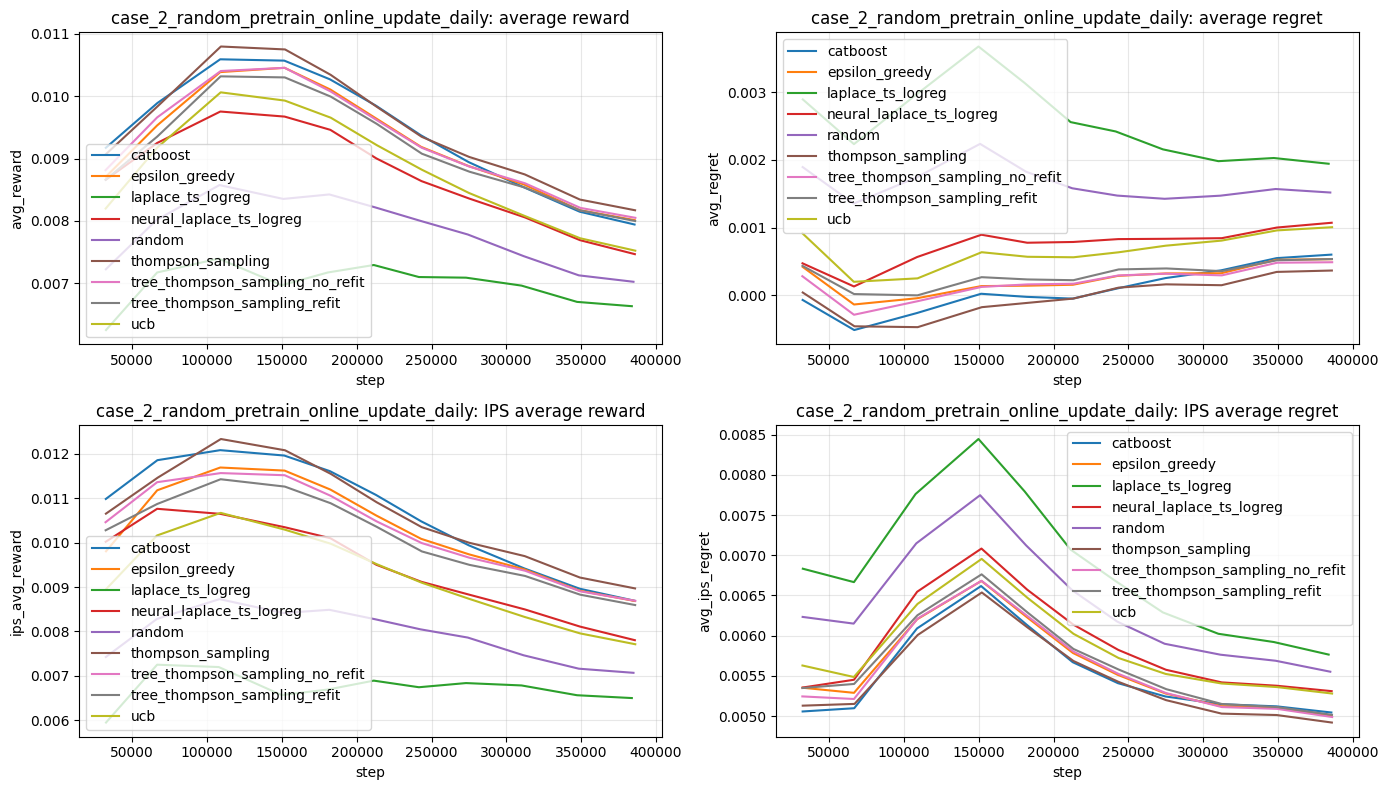

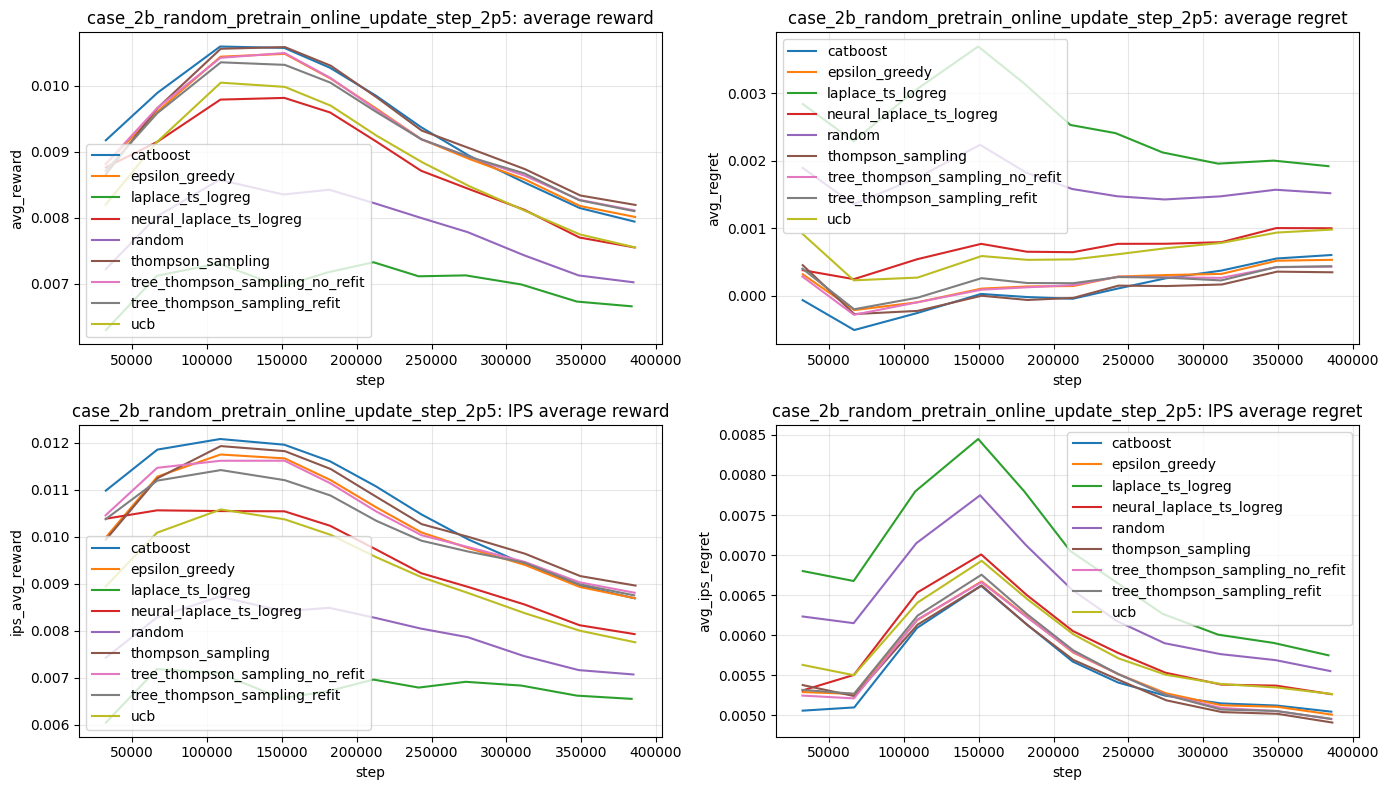

In [7]:
if not history_df.empty:
    for scenario_name, part in history_df.groupby('scenario'):
        fig, axes = plt.subplots(2, 2, figsize=(14, 8))

        for algo, algo_df in part.groupby('algo'):
            max_step = int(algo_df['step'].max()) if len(algo_df) else 0
            stride = max(1, int(round(max_step * 0.05)))  # каждые 5%
            ds = algo_df.iloc[stride::stride] if len(algo_df) > stride else algo_df  # стартуем с 5%

            axes[0, 0].plot(ds['step'], ds['avg_reward'], label=algo)
            axes[0, 1].plot(ds['step'], ds['avg_regret'], label=algo)
            axes[1, 0].plot(ds['step'], ds['ips_avg_reward'], label=algo)
            axes[1, 1].plot(ds['step'], ds['avg_ips_regret'], label=algo)

        axes[0, 0].set_title(f'{scenario_name}: average reward')
        axes[0, 0].set_xlabel('step')
        axes[0, 0].set_ylabel('avg_reward')

        axes[0, 1].set_title(f'{scenario_name}: average regret')
        axes[0, 1].set_xlabel('step')
        axes[0, 1].set_ylabel('avg_regret')

        axes[1, 0].set_title(f'{scenario_name}: IPS average reward')
        axes[1, 0].set_xlabel('step')
        axes[1, 0].set_ylabel('ips_avg_reward')

        axes[1, 1].set_title(f'{scenario_name}: IPS average regret')
        axes[1, 1].set_xlabel('step')
        axes[1, 1].set_ylabel('avg_ips_regret')

        for ax in axes.ravel():
            ax.grid(True, alpha=0.3)
            ax.legend()

        fig.tight_layout()
        plt.show()
else:
    print('History is empty.')


## 6) График sensitive IPS metrics
Показывает `ips_ctr_sensitive` и `ips_regret_sens` по алгоритмам внутри каждого сценария.

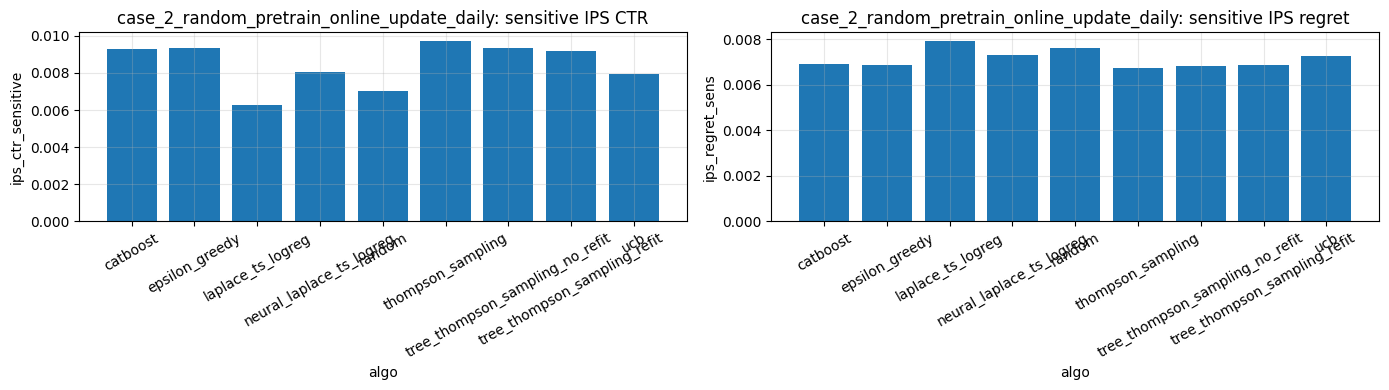

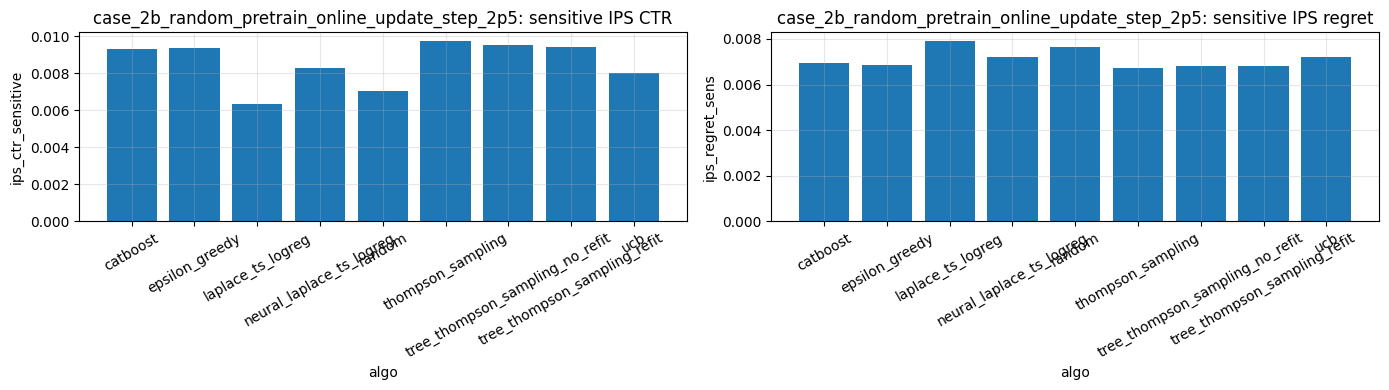

In [8]:
if set(sensitive_cols).issubset(metrics_df.columns):
    sensitive_plot_df = metrics_df[sensitive_cols].copy()
    sensitive_plot_df = sensitive_plot_df[sensitive_plot_df['sensitive_impressions'] > 0]

    if sensitive_plot_df.empty:
        print('Нет данных для sensitive IPS графика (sensitive_impressions == 0).')
    else:
        for scenario_name, part in sensitive_plot_df.groupby('scenario'):
            fig, axes = plt.subplots(1, 2, figsize=(14, 4))
            part = part.sort_values('algo')

            axes[0].bar(part['algo'], part['ips_ctr_sensitive'])
            axes[0].set_title(f'{scenario_name}: sensitive IPS CTR')
            axes[0].set_xlabel('algo')
            axes[0].set_ylabel('ips_ctr_sensitive')
            axes[0].tick_params(axis='x', rotation=30)

            axes[1].bar(part['algo'], part['ips_regret_sens'])
            axes[1].set_title(f'{scenario_name}: sensitive IPS regret')
            axes[1].set_xlabel('algo')
            axes[1].set_ylabel('ips_regret_sens')
            axes[1].tick_params(axis='x', rotation=30)

            for ax in axes:
                ax.grid(True, alpha=0.3)

            fig.tight_layout()
            plt.show()
else:
    print('Sensitive IPS колонки отсутствуют в metrics_df.')


## 6.1) Sensitive IPS метрики по шагам
Показывает динамику sensitive-метрик, которые теперь логируются в `history_df`.


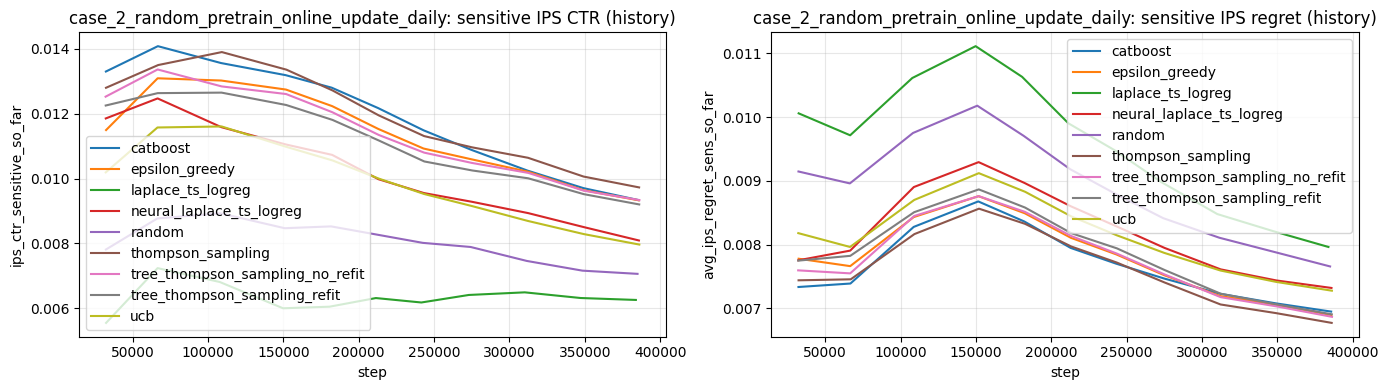

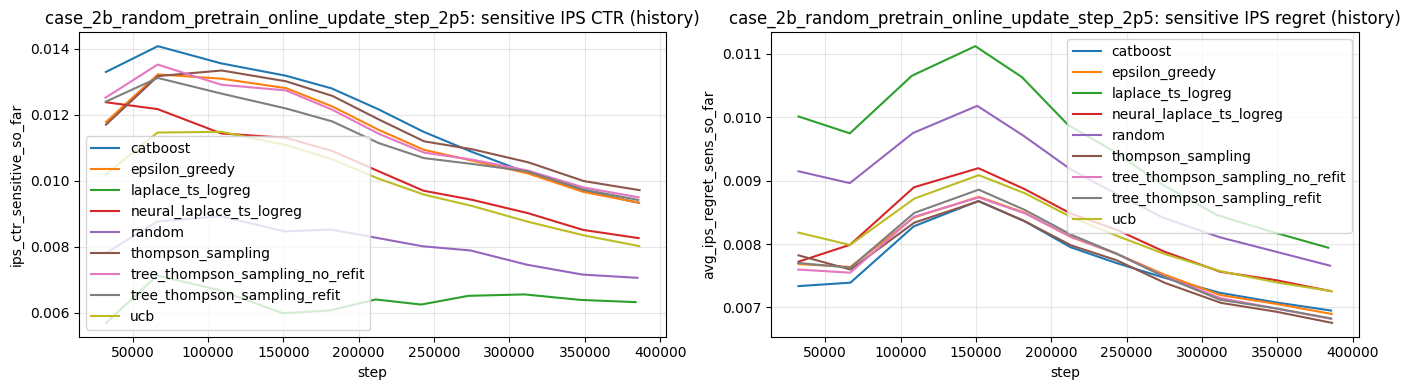

In [9]:
if not history_df.empty and {'ips_ctr_sensitive_so_far', 'avg_ips_regret_sens_so_far'}.issubset(history_df.columns):
    for scenario_name, part in history_df.groupby('scenario'):
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))

        for algo, algo_df in part.groupby('algo'):
            max_step = int(algo_df['step'].max()) if len(algo_df) else 0
            stride = max(1, int(round(max_step * 0.05)))
            ds = algo_df.iloc[stride::stride] if len(algo_df) > stride else algo_df

            axes[0].plot(ds['step'], ds['ips_ctr_sensitive_so_far'], label=algo)
            axes[1].plot(ds['step'], ds['avg_ips_regret_sens_so_far'], label=algo)

        axes[0].set_title(f'{scenario_name}: sensitive IPS CTR (history)')
        axes[0].set_xlabel('step')
        axes[0].set_ylabel('ips_ctr_sensitive_so_far')

        axes[1].set_title(f'{scenario_name}: sensitive IPS regret (history)')
        axes[1].set_xlabel('step')
        axes[1].set_ylabel('avg_ips_regret_sens_so_far')

        for ax in axes:
            ax.grid(True, alpha=0.3)
            ax.legend()

        fig.tight_layout()
        plt.show()
else:
    print('Нет sensitive history-метрик в history_df.')



## 7) Графики по статистикам action'ов
Показывает динамику общего числа уникальных action'ов и количества новых action'ов по дням/checkpoint'ам.

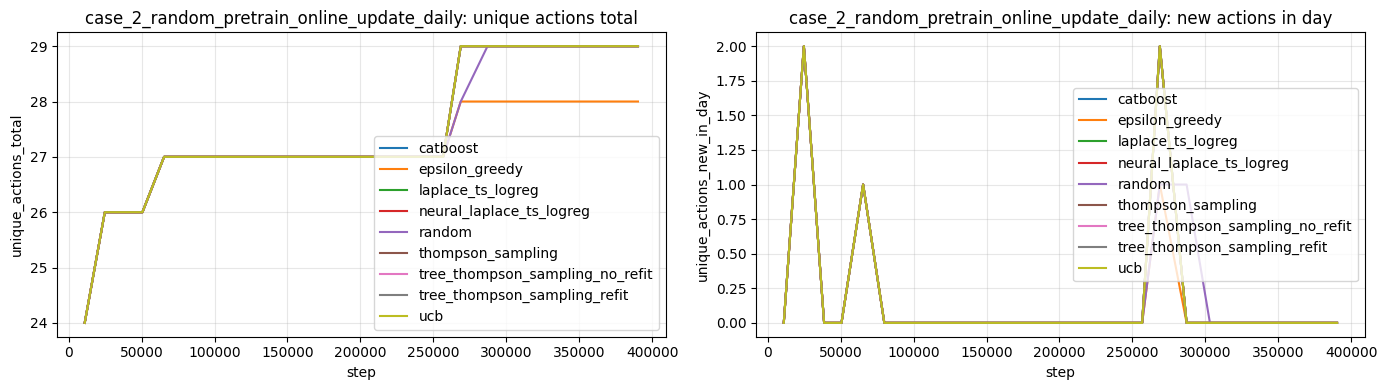

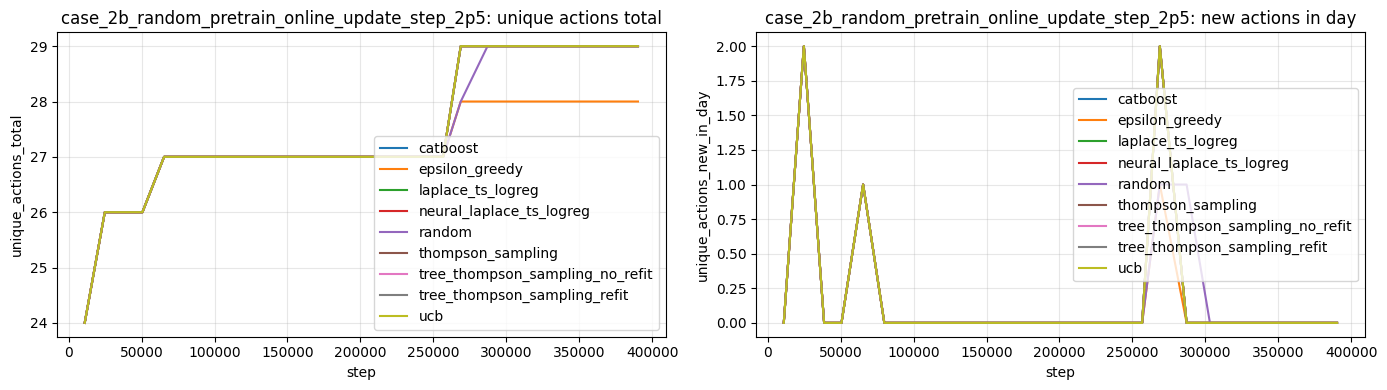

In [10]:
if not action_stats_df.empty:
    for scenario_name, part in action_stats_df.groupby('scenario'):
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))

        for algo, algo_df in part.groupby('algo'):
            algo_df = algo_df.sort_values('step')
            axes[0].plot(algo_df['step'], algo_df['unique_actions_total'], label=algo)
            axes[1].plot(algo_df['step'], algo_df['unique_actions_new_in_day'], label=algo)

        axes[0].set_title(f"{scenario_name}: unique actions total")
        axes[0].set_xlabel('step')
        axes[0].set_ylabel('unique_actions_total')

        axes[1].set_title(f"{scenario_name}: new actions in day")
        axes[1].set_xlabel('step')
        axes[1].set_ylabel('unique_actions_new_in_day')

        for ax in axes:
            ax.grid(True, alpha=0.3)
            ax.legend()

        fig.tight_layout()
        plt.show()
else:
    print('action_stats_df is empty.')


## 8) Распределение показов по action и дням


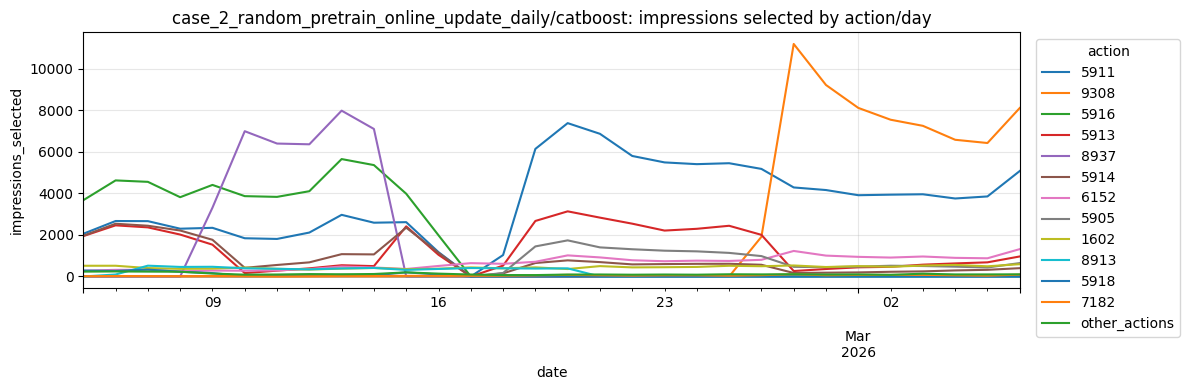

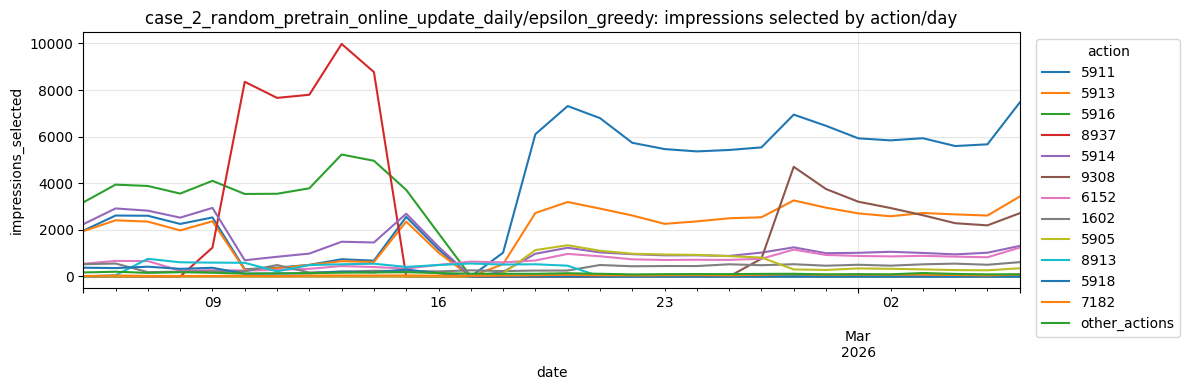

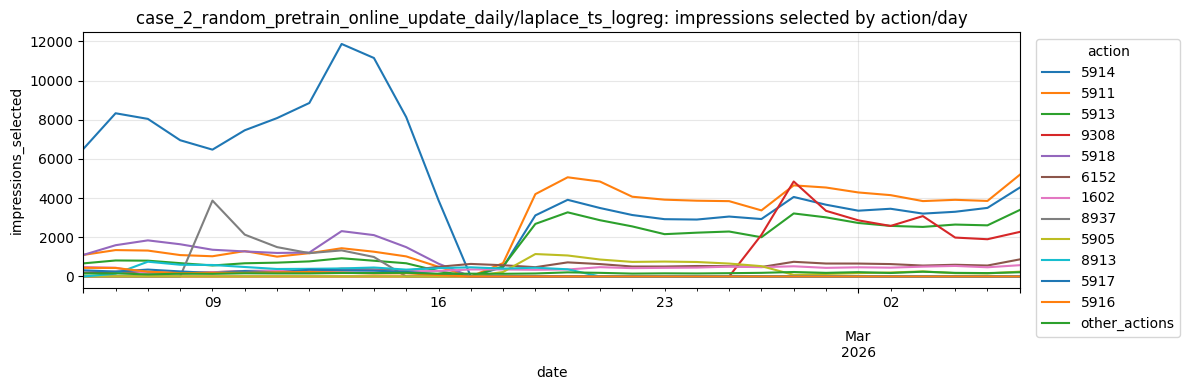

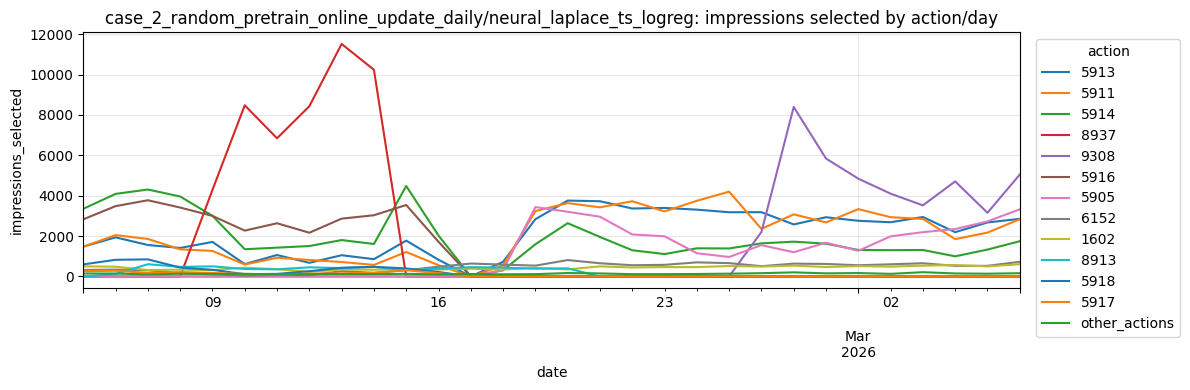

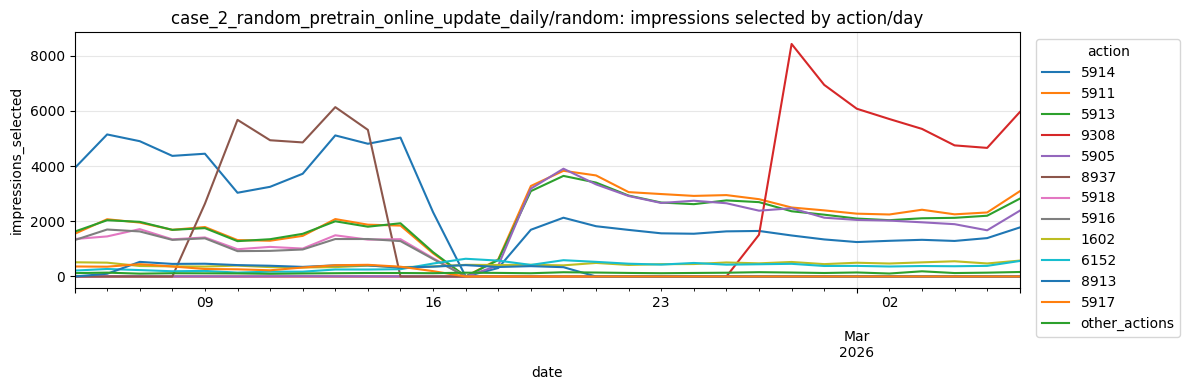

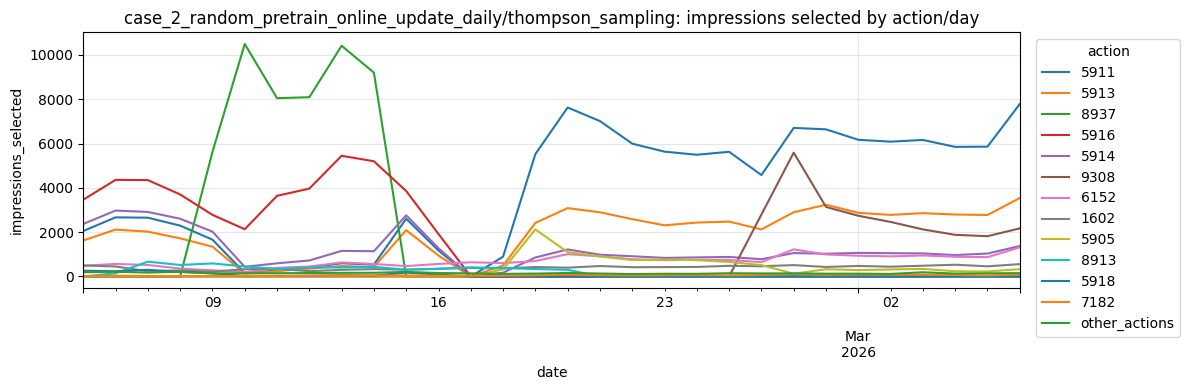

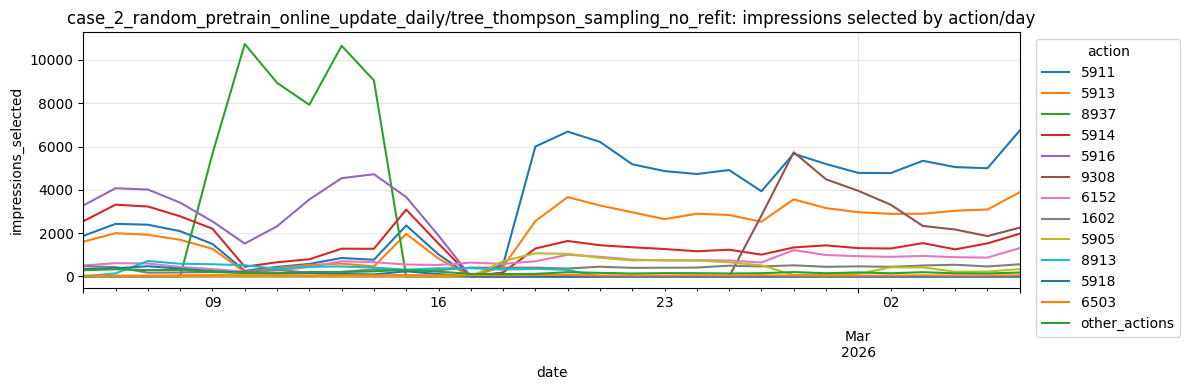

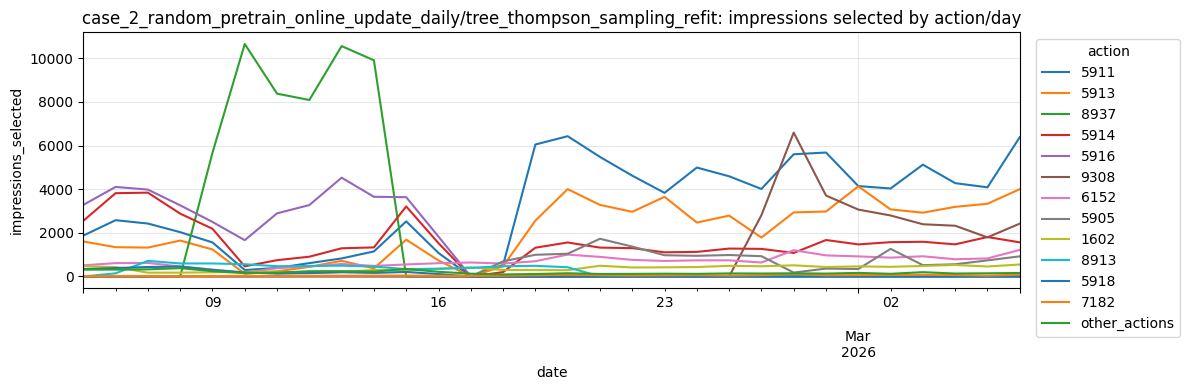

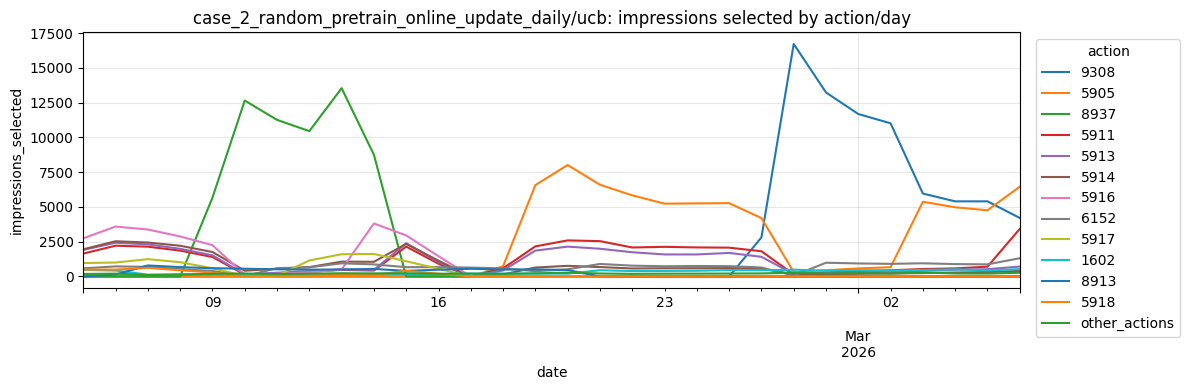

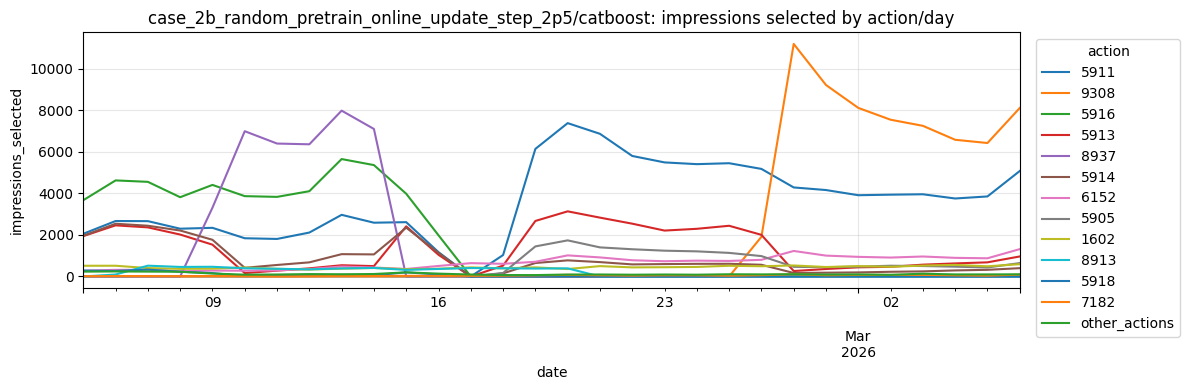

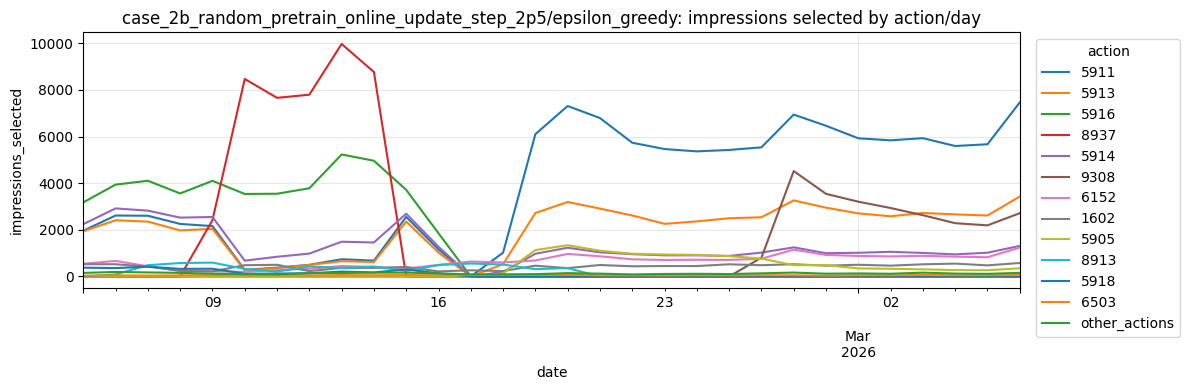

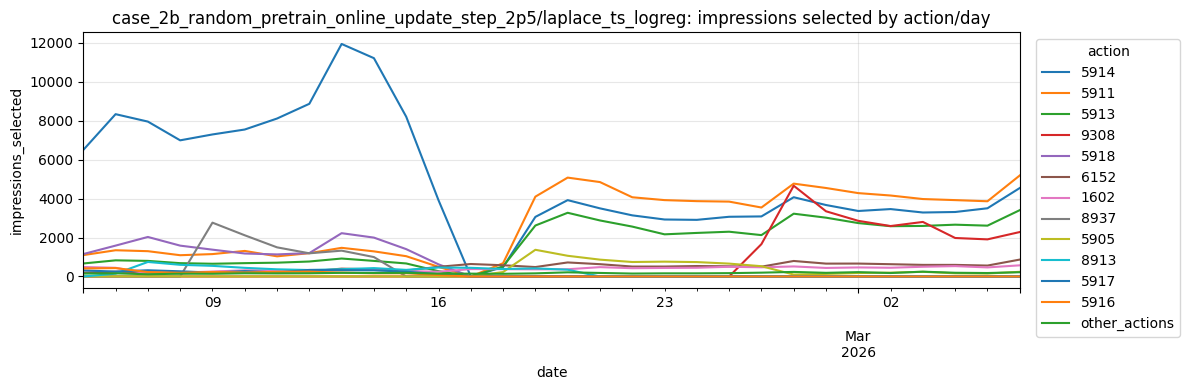

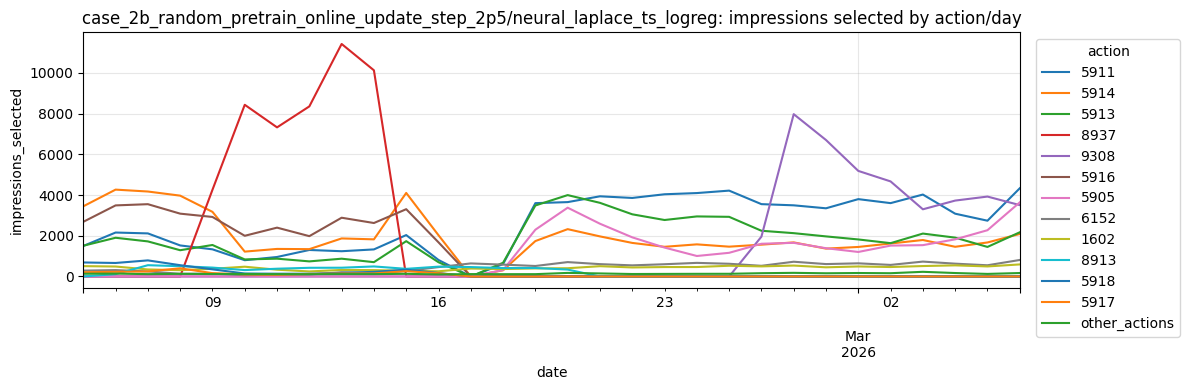

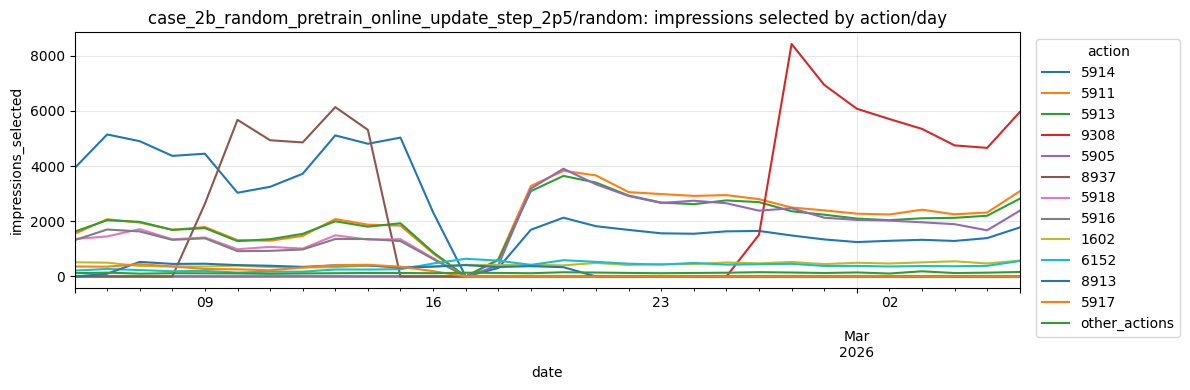

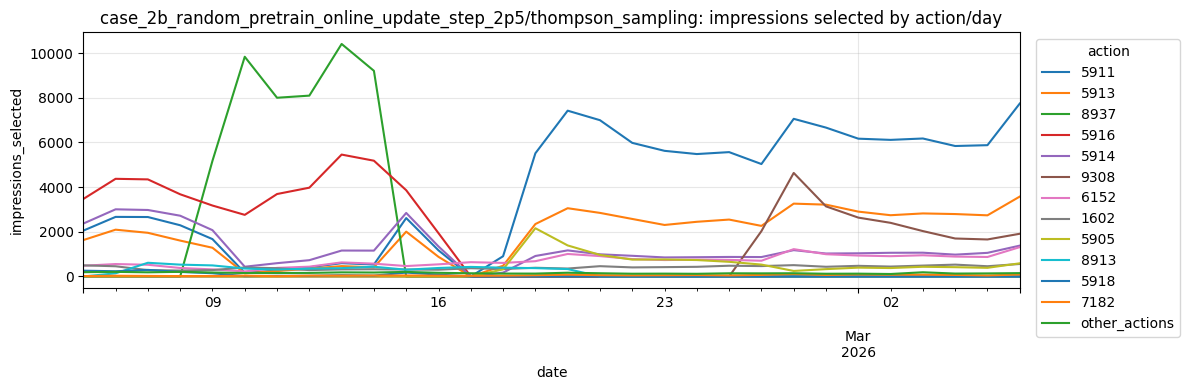

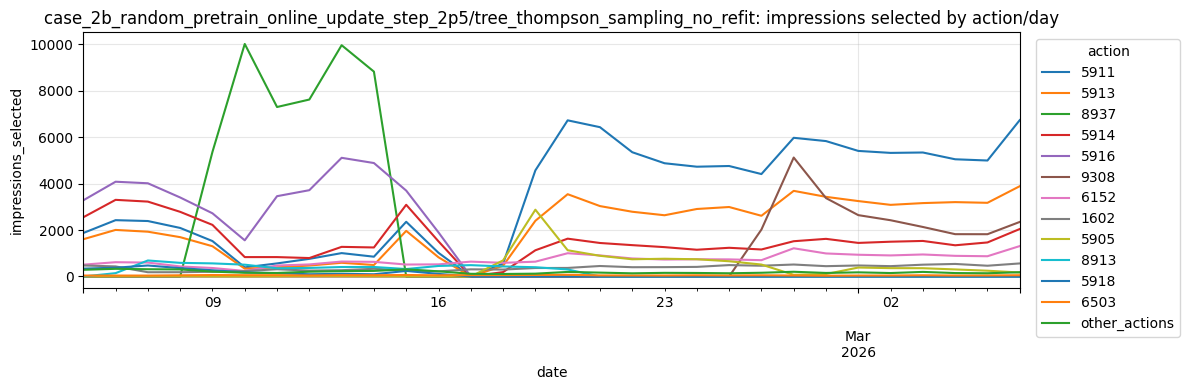

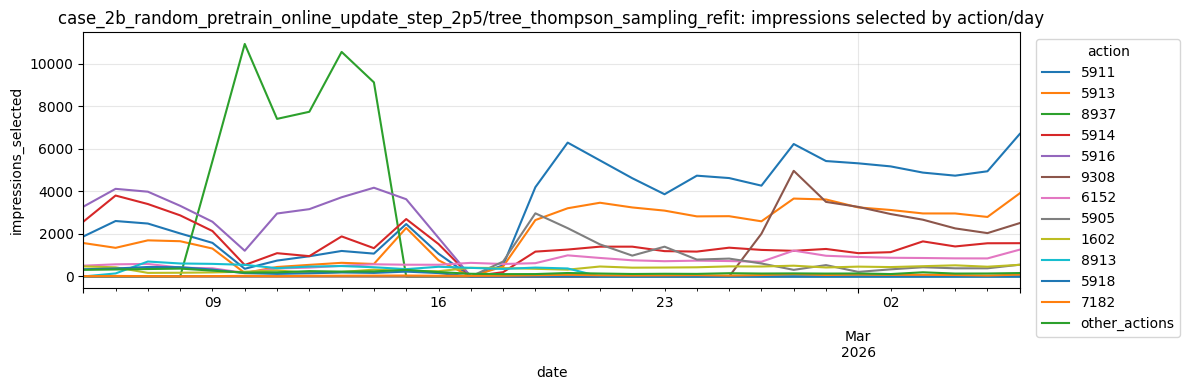

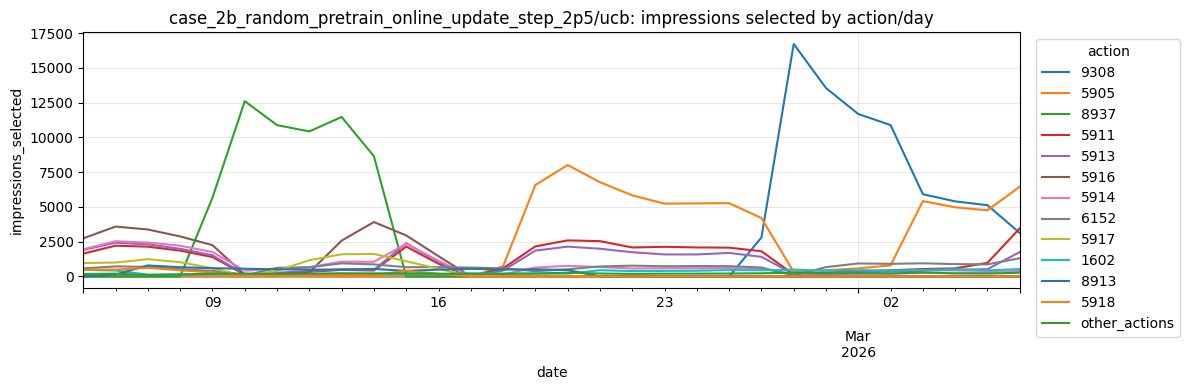

In [11]:
if not action_daily_stats_df.empty:
    top_actions_n = 12

    for scenario_name, part in action_daily_stats_df.groupby('scenario'):
        for algo_name, algo_df in part.groupby('algo'):
            pivot_cnt = algo_df.pivot_table(index='date', columns='action', values='impressions_selected', aggfunc='sum').fillna(0)

            if pivot_cnt.shape[1] > top_actions_n:
                action_totals = pivot_cnt.sum(axis=0).sort_values(ascending=False)
                top_actions = action_totals.head(top_actions_n).index
                other_actions = [a for a in pivot_cnt.columns if a not in top_actions]

                plot_df = pivot_cnt.loc[:, top_actions].copy()
                if other_actions:
                    plot_df['other_actions'] = pivot_cnt.loc[:, other_actions].sum(axis=1)
            else:
                plot_df = pivot_cnt.copy()

            fig, ax = plt.subplots(figsize=(12, 4))
            plot_df.sort_index().plot(ax=ax)
            ax.set_title(f'{scenario_name}/{algo_name}: impressions selected by action/day')
            ax.set_xlabel('date')
            ax.set_ylabel('impressions_selected')
            ax.grid(True, alpha=0.3)
            ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), title='action')
            fig.tight_layout()
            plt.show()
else:
    print('action_daily_stats_df is empty.')


## 9) Сохранение артефактов

In [12]:
OUT_DIR = ARTIFACTS_DIR
OUT_DIR.mkdir(parents=True, exist_ok=True)

metrics_path = OUT_DIR / 'metrics.csv'
history_path = OUT_DIR / 'history.csv'
action_stats_path = OUT_DIR / 'action_stats.csv'
action_daily_stats_path = OUT_DIR / 'action_daily_stats.csv'

metrics_df.to_csv(metrics_path, index=False)
history_df.to_csv(history_path, index=False)
action_stats_df.to_csv(action_stats_path, index=False)
action_daily_stats_df.to_csv(action_daily_stats_path, index=False)

print('saved metrics:', metrics_path)
print('saved history:', history_path)
print('saved action stats:', action_stats_path)
print('saved action daily stats:', action_daily_stats_path)


saved metrics: /Users/ogrobertino/BanditsResearch/artifacts/banner_big/metrics.csv
saved history: /Users/ogrobertino/BanditsResearch/artifacts/banner_big/history.csv
saved action stats: /Users/ogrobertino/BanditsResearch/artifacts/banner_big/action_stats.csv
saved action daily stats: /Users/ogrobertino/BanditsResearch/artifacts/banner_big/action_daily_stats.csv
